# **Telecom X — Customer Churn Prediction**

## Machine Learning Project

This project aims to build predictive models to identify customers who are likely to cancel their services at Telecom X.

Using the cleaned dataset from the previous analysis phase, we will prepare the data for machine learning, train classification models, evaluate their performance, and identify the most important variables influencing customer churn.

## Business Objective

Telecom X is experiencing a high rate of customer churn and wants to anticipate which customers are most likely to cancel their services.

The objective of this project is to develop a predictive pipeline that allows the company to detect potential churn cases early and design targeted retention strategies.

## Project Workflow

The machine learning pipeline will include the following steps:

1. Load the cleaned dataset
2. Remove irrelevant variables
3. Encode categorical variables
4. Analyze churn class distribution
5. Correlation analysis
6. Split data into training and testing sets
7. Train classification models
8. Evaluate model performance
9. Analyze feature importance
10. Generate business conclusions

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set_style('whitegrid')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Data

In [3]:
data = pd.read_csv('/content/drive/MyDrive/Telecom_Parte_1/Telecom_churn_clean.csv')
data.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## Initial Data Inspection

In [4]:
data.shape

(7267, 21)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Here we can see that the churn column **contains null values**, which shouldn’t happen in a dataset used for ML, so we need to fix that... the data is 7043 from 7267

In [6]:
data.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2277.182035
std,0.369074,24.571773,30.129572,2268.648587
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.425000,396.200000
50%,0.000000,29.000000,70.300000,1389.200000
75%,0.000000,55.000000,89.875000,3778.525000
max,1.000000,72.000000,118.750000,8684.800000


## Removing Irrelevant Columns

In [7]:
data = data.drop(columns=['customerID'])

The column **customerID** was removed because it represents a unique number that does not contribute to the predictive model.

Additionally, rows with missing values in the target variable `Churn` were removed, since supervised learning models require a known target value for training.

### Let’s remove the null values from the Churn column.

In [8]:
data = data.dropna(subset=['Churn'])

In [9]:
#Let's verify is already corrected
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
 17  

##Encoding
Since we have many object-type columns, and ML models require numeric inputs, we need to convert the binary columns (Yes/No) into 1s and 0s.

In [10]:
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

In [11]:
data['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [12]:
data.select_dtypes(include='object').columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

### One-Hot Encoding
To make categorical variables compatible with machine learning models, we apply one-hot encoding using **pandas.get_dummies()**.

One-hot encoding converts categorical variables into binary indicator variables.  
Each category becomes a separate column with values 0 or 1 indicating the absence or presence of that category.

In [13]:
#drop_first=True helps avoid multicollinearity, which is important for models like Logistic Regression.
data_encoded = pd.get_dummies(data,drop_first=True)

In [14]:
data_encoded.head(2)

,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65.6,593.3,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.4,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True


In [15]:
data_encoded.shape

(7043, 31)

## Checking the Churn proportion

In [16]:
churn = data_encoded['Churn'].value_counts(normalize=True)
print(churn)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


**This means that 73% of clients did not cancel (0), while 27% canceled (1).**

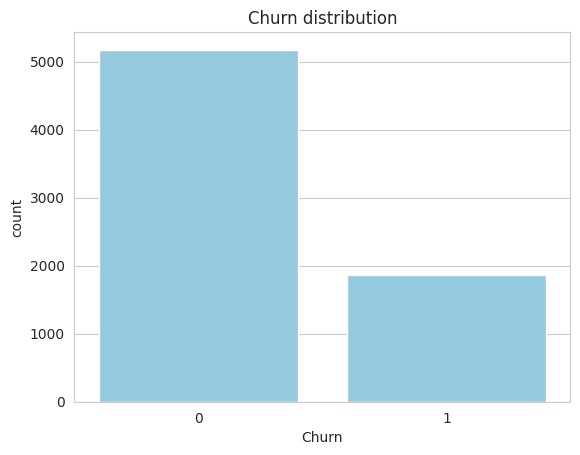

In [17]:
sns.countplot(x='Churn',data=data_encoded,color='skyblue')
plt.title('Churn distribution')
plt.show()

The dataset shows an imbalance, with a higher proportion of customers who did not churn compared to those who did.

Although the imbalance is not extreme, it should be considered when evaluating model performance.

**However this is important since we will see affected: accuracy, recaal and F1-score**

## **Correlation Analysis**

Here, we are going to look for the following:

* Which variables are most related to churn
* Which factors explain why customers churn

In [18]:
correlation_matrix = data_encoded.corr()

Now let’s visualize it.
Instead of showing the full matrix (which would be very large), we’ll do something more useful: **focus only on the correlations with Churn.**

In [19]:
churn_corr = correlation_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
Charges.Monthly                          0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


What do we see here?

**The top variables related to churn include:** Contract_two_year, InternetService_No, TechSupport_Yes, and Dependents_Yes.


For example, tenure has a correlation of -0.352, indicating that the longer a client stays with the service, the less likely they are to churn.


In contrast, variables like gender, which have correlations close to 0, have little to no impact on churn.

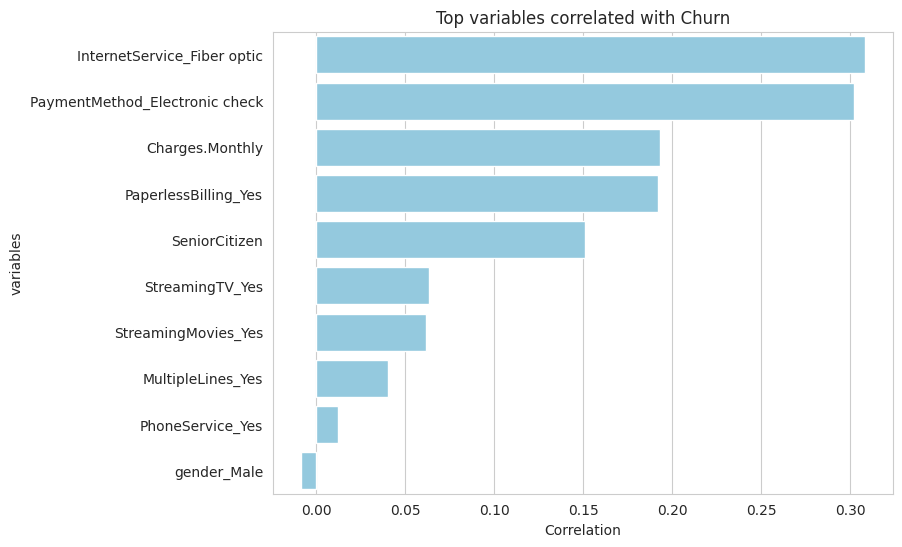

In [20]:
#let's visualize the top variables
top_corr = churn_corr.drop('Churn').head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index, color='skyblue')

plt.title('Top variables correlated with Churn')
plt.xlabel('Correlation')
plt.ylabel('variables')

plt.show()

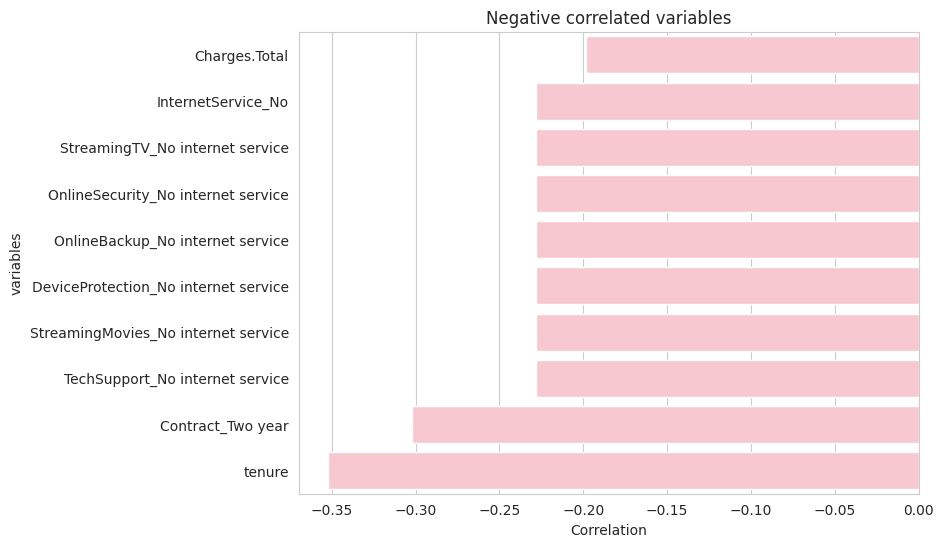

In [21]:
#let's visualize the bottom variables or negative correlation

bottom_corr = churn_corr.drop('Churn').tail(10)

plt.figure(figsize=(8,6))
sns.barplot(x=bottom_corr.values, y=bottom_corr.index, color='pink')

plt.title('Negative correlated variables')
plt.xlabel('Correlation')
plt.ylabel('variables')

plt.show()

## Splitting Features and Target

In [22]:
X = data_encoded.drop('Churn', axis=1)
y = data_encoded['Churn']

In [23]:
X.head(2)

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.3,False,True,True,True,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.4,True,False,False,True,False,True,...,False,False,False,True,False,False,False,False,False,True


In [24]:
y.head(2)

,Churn
0,0
1,0


In [25]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [26]:
X_train.shape, X_test.shape

((4930, 30), (2113, 30))

In [27]:
y_train.shape, y_test.shape

((4930,), (2113,))

The dataset was split into training and testing sets using a 70/30 ratio.

A stratified split was applied to preserve the original proportion of churn and non-churn cases in both subsets, which is important because the target classes are imbalanced.

## Feature Scaling

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()

* With fit_transform(X_train) the model learns the mean and standard deviation of the data, and then applies the transformation.

* transform(X_test) applies the same transformation learned from the training set, which helps prevent data leakage.

In [30]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
#just to verify
X_train_scaled[5:]

array([[-0.43781822,  1.52378106,  1.19431009, ...,  1.89481307,
        -0.70603133, -0.54061758],
       [-0.43781822, -0.59068219,  0.98358413, ..., -0.52775655,
         1.41636774, -0.54061758],
       [-0.43781822, -0.95664698, -1.48373476, ..., -0.52775655,
        -0.70603133,  1.84973638],
       ...,
       [-0.43781822, -0.42803117, -1.47211994, ..., -0.52775655,
        -0.70603133, -0.54061758],
       [-0.43781822, -0.34670566, -1.34103844, ..., -0.52775655,
        -0.70603133,  1.84973638],
       [-0.43781822, -0.91598423, -1.45718661, ..., -0.52775655,
         1.41636774, -0.54061758]])

##**Generating our baseline model**

## **Logistic Regression Model**

Logistic Regression will be use as a baseline classification model to predict customer churn.

The model will be trained using the standardized training dataset and then evaluated on the test dataset.

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
#creating it
log_model = LogisticRegression(max_iter=1000)

### Training the model

In [34]:
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

### Making predictions

In [35]:
y_pred = log_model.predict(X_test_scaled)

In [36]:
#let's import it
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.7979176526265973


### Confusion Matrix

In [37]:
from sklearn.metrics import confusion_matrix

cm= confusion_matrix(y_test, y_pred)
print(cm)

[[1380  172]
 [ 255  306]]


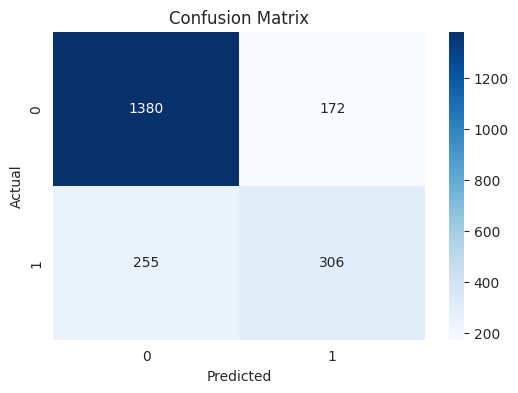

In [38]:
#let's visualize it

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

**Correct predictions**
True Negatives = 1380
Clients who were not going to churn, and the model predicted this correctly.

True Positives = 306
Clients who did churn, and the model successfully identified them.

**Model errors**
False Positives = 172
The model predicted churn, but the clients did not churn.

False Negatives ** = 255
Clients who actually churned, but the model failed to detect them.

*This metric is critical because these are customers we lose without any prior warning.*

### Classification Report

In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



###**Feature Importance (Logistic Regression coefficients)**

In [40]:
coeff = log_model.coef_[0]

feature_importance = pd.DataFrame({
                        'Feature': X.columns,
                        'Coefficient': coeff
                        })

feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)
feature_importance.head(5)

,Feature,Coefficient
3,Charges.Total,0.741711
10,InternetService_Fiber optic,0.547366
26,PaperlessBilling_Yes,0.202041
28,PaymentMethod_Electronic check,0.172494
21,StreamingTV_Yes,0.166033


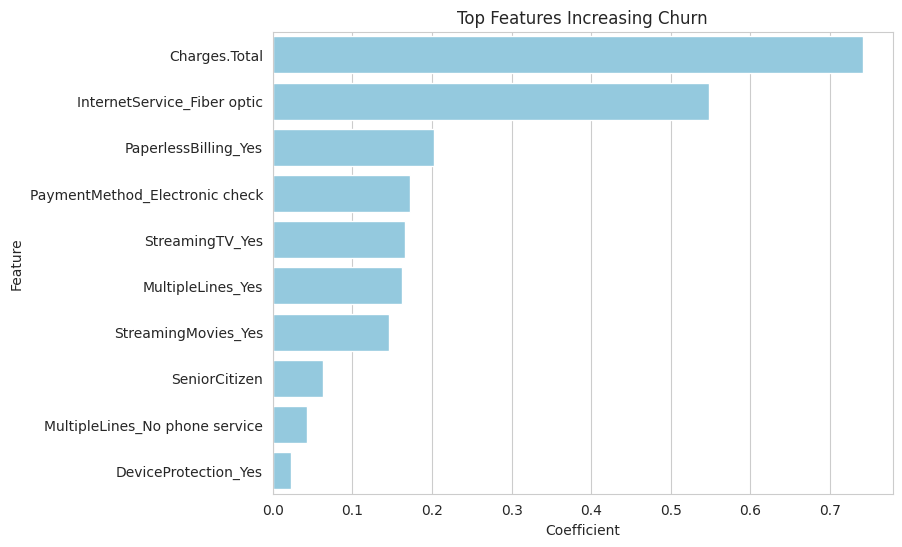

In [41]:
top_positive = feature_importance.head(10)

plt.figure(figsize=(8,6))
sns.barplot(x='Coefficient', y='Feature', data=top_positive, color='skyblue')

plt.title('Top Features Increasing Churn')
plt.show()

### Feature Importance Interpretation

The coefficients from the Logistic Regression model reveal which features contribute the most to predicting customer churn.

Features with **positive coefficients** increase the probability of churn, while features with **negative coefficients** decrease churn likelihood.

The most influential features associated with higher churn probability include:

- **Charges.Total** – customers who have paid higher total charges tend to churn more.
- **InternetService_Fiber optic** – customers with fiber optic internet service show a higher likelihood of canceling.
- **PaperlessBilling_Yes** – paperless billing is associated with increased churn.
- **PaymentMethod_Electronic check** – customers paying via electronic check tend to churn more frequently.
- **StreamingTV_Yes** – customers subscribed to streaming TV services show slightly higher churn.

These insights align with the exploratory data analysis performed earlier and highlight potential business areas where customer retention strategies could be applied.

## **Second Model, Random Forest**

In [42]:
from sklearn.ensemble import RandomForestClassifier


In [43]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [44]:
y_pred_rf = rf_model.predict(X_test)

In [45]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print('Random Forest Accuracy:', accuracy_rf)

Random Forest Accuracy: 0.7851396119261713


### Confussion Matrix for Random Forest

In [47]:
from sklearn.metrics import confusion_matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[1389  163]
 [ 291  270]]


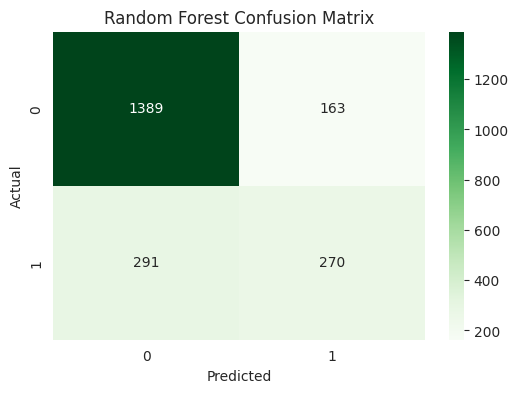

In [48]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

### Clasification Report

In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.62      0.48      0.54       561

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.70      2113
weighted avg       0.77      0.79      0.78      2113



## **Decision Tree Model**

In [52]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [53]:
#Predictions
y_pred_dt = dt_model.predict(X_test)

In [55]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print('Decision Tree Accuracy:', accuracy_dt)

Decision Tree Accuracy: 0.73450070989115


### Confusion Matrix

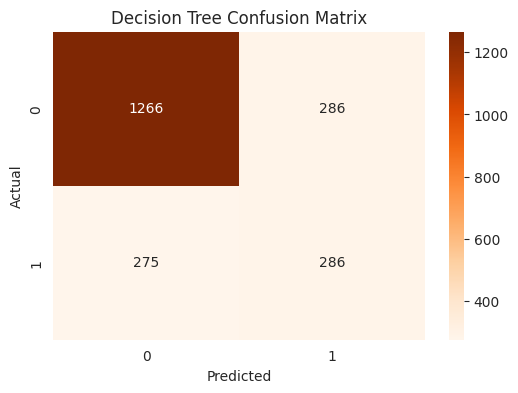

In [57]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')

plt.show()

In [58]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1552
           1       0.50      0.51      0.50       561

    accuracy                           0.73      2113
   macro avg       0.66      0.66      0.66      2113
weighted avg       0.74      0.73      0.74      2113



## **Model Accuracy Comparison**

In [60]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy,
        accuracy_rf,
        accuracy_dt
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.797918
1,Random Forest,0.785140
2,Decision Tree,0.734501


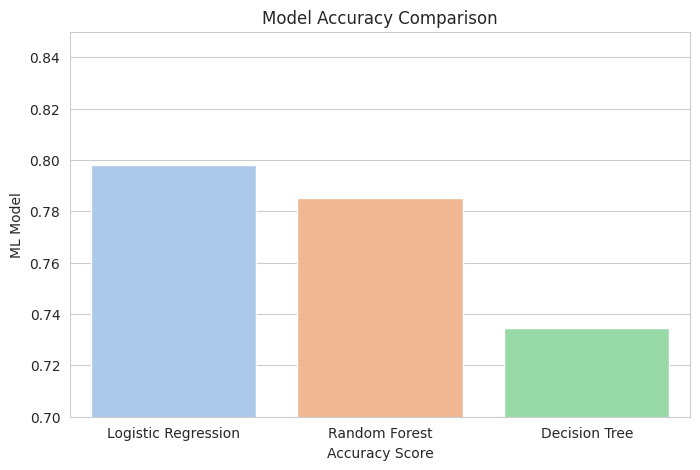

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    hue='Model',
    data=model_results,
    palette='pastel',
    legend=False

)

plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy Score')
plt.ylabel('ML Model')

plt.ylim(0.7, 0.85)
plt.show()

## **Model Comparison**

Three machine learning models were evaluated to predict customer churn:

- Logistic Regression
- Random Forest
- Decision Tree

Logistic Regression achieved the highest accuracy with approximately **79.8%**, slightly outperforming Random Forest and Decision Tree models.

This suggests that the relationship between the features and churn in this dataset can be effectively captured by a relatively simple linear model.

Decision Tree showed the lowest performance, which may indicate that a single tree is not complex enough to capture all the patterns in the data.

Random Forest improved over the single tree but still performed slightly below Logistic Regression.

## **Business Insights**

The analysis suggests that customers with higher monthly charges, fiber optic internet service, and electronic check payment methods are more likely to churn.

Customers with longer tenure and long-term contracts are significantly less likely to leave.

These insights could help the company design targeted retention strategies, such as offering incentives for long-term contracts or improving service satisfaction for fiber optic users.

## **Conclusion**

The analysis aimed to identify the main factors associated with customer churn and build predictive models to anticipate customer cancellations.

Among the evaluated models, Logistic Regression achieved the highest performance with an accuracy close to 80%, slightly outperforming Random Forest and Decision Tree models.

Beyond model performance, the analysis revealed several factors strongly associated with churn. Customers with fiber optic internet service, higher monthly charges, and electronic check payment methods showed a higher probability of leaving the service.

On the other hand, customers with longer tenure and long-term contracts were significantly less likely to churn.

These findings suggest that retention strategies could focus on improving the experience of high-value customers and encouraging longer contract commitments.